In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
import spk_feat_cluster_comp_analysis
importlib.reload(spk_feat_cluster_comp_analysis)
from spk_feat_cluster_comp_analysis import (
    compile_experiment_results,
    analyze_cross_correlations,
    plot_sig_feat_pairs,
    plot_meta_spk_feature_dependency,
    stat_test_metadata_dependency,
    plot_feature_depth_distribution,
    stat_test_depth_stratification,
)
import config

CLUSTER_PKL_DIR = config.SPE1_PICKLE_ROOT + '/cluster_pickles/'

In [2]:
df_master = compile_experiment_results(CLUSTER_PKL_DIR)

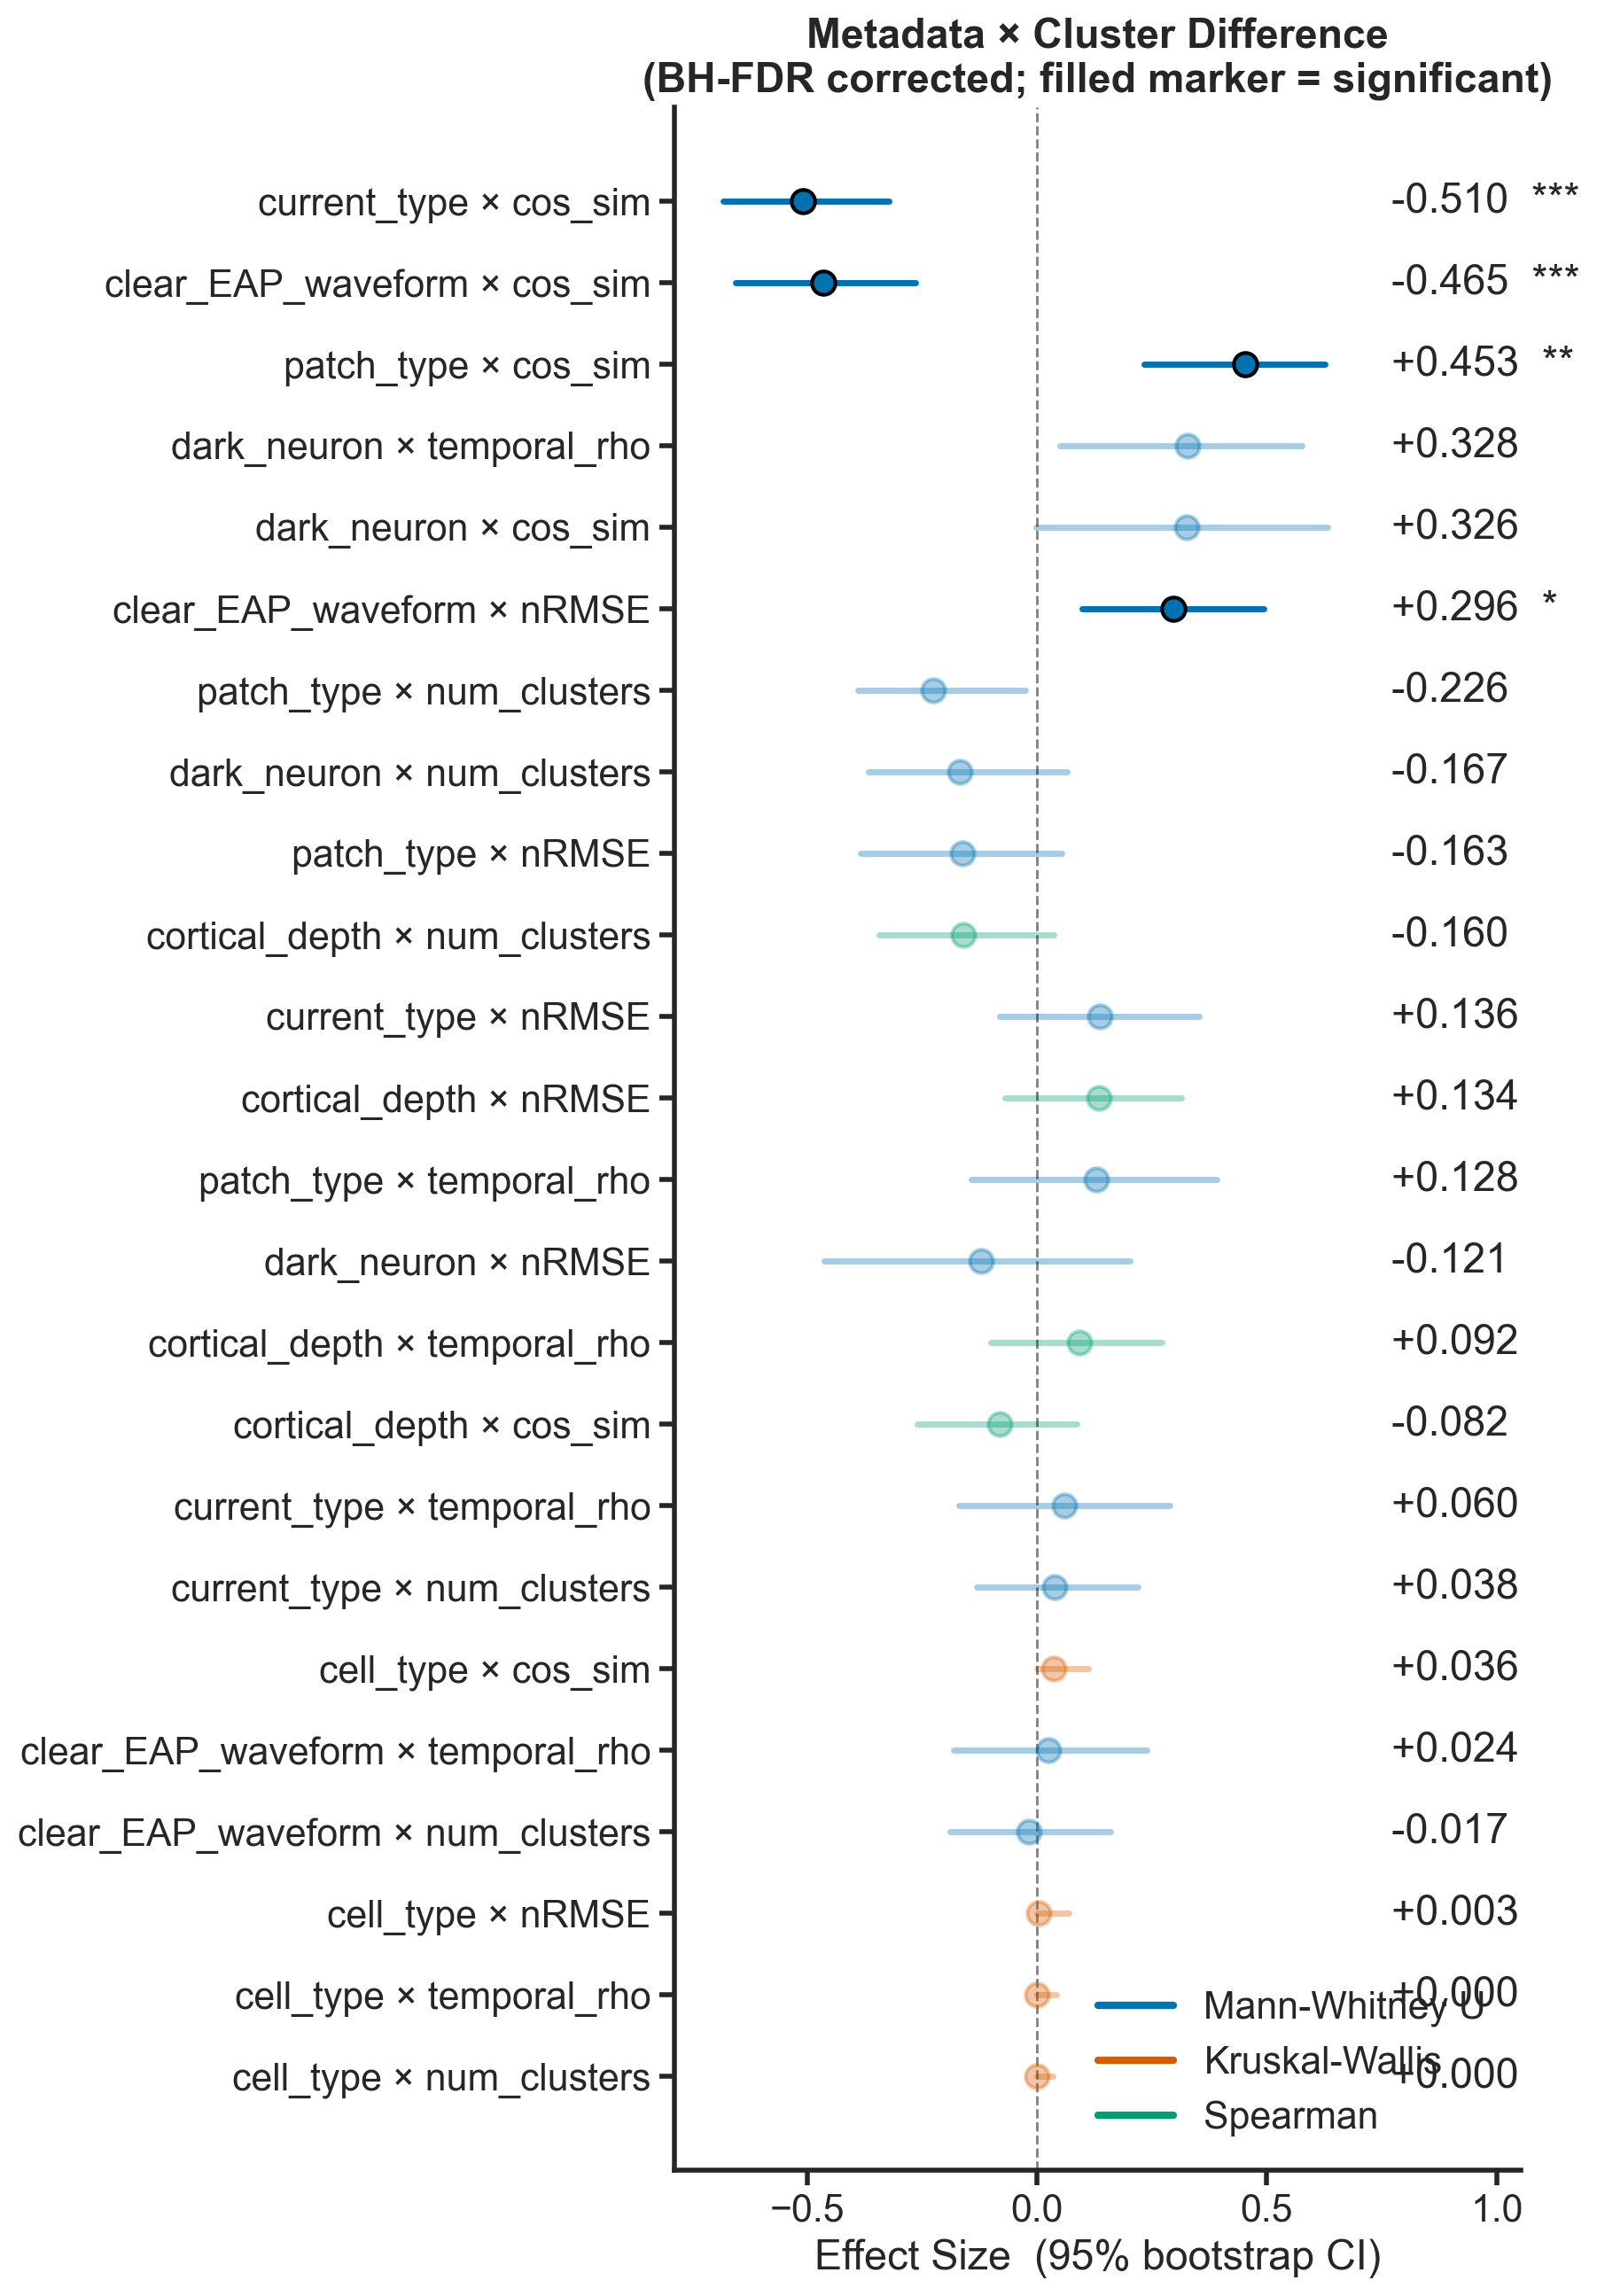


4/24 pairs significant after BH-FDR (α=0.05, n_bootstrap=1000):
  current_type           × cos_sim        | rank-biserial r = -0.510  95% CI [-0.683, -0.322]  p_fdr=0.0001 ***
  clear_EAP_waveform     × cos_sim        | rank-biserial r = -0.465  95% CI [-0.656, -0.265]  p_fdr=0.0002 ***
  patch_type             × cos_sim        | rank-biserial r = +0.453  95% CI [+0.233, +0.627]  p_fdr=0.0083 **
  clear_EAP_waveform     × nRMSE          | rank-biserial r = +0.296  95% CI [+0.099, +0.494]  p_fdr=0.0406 *


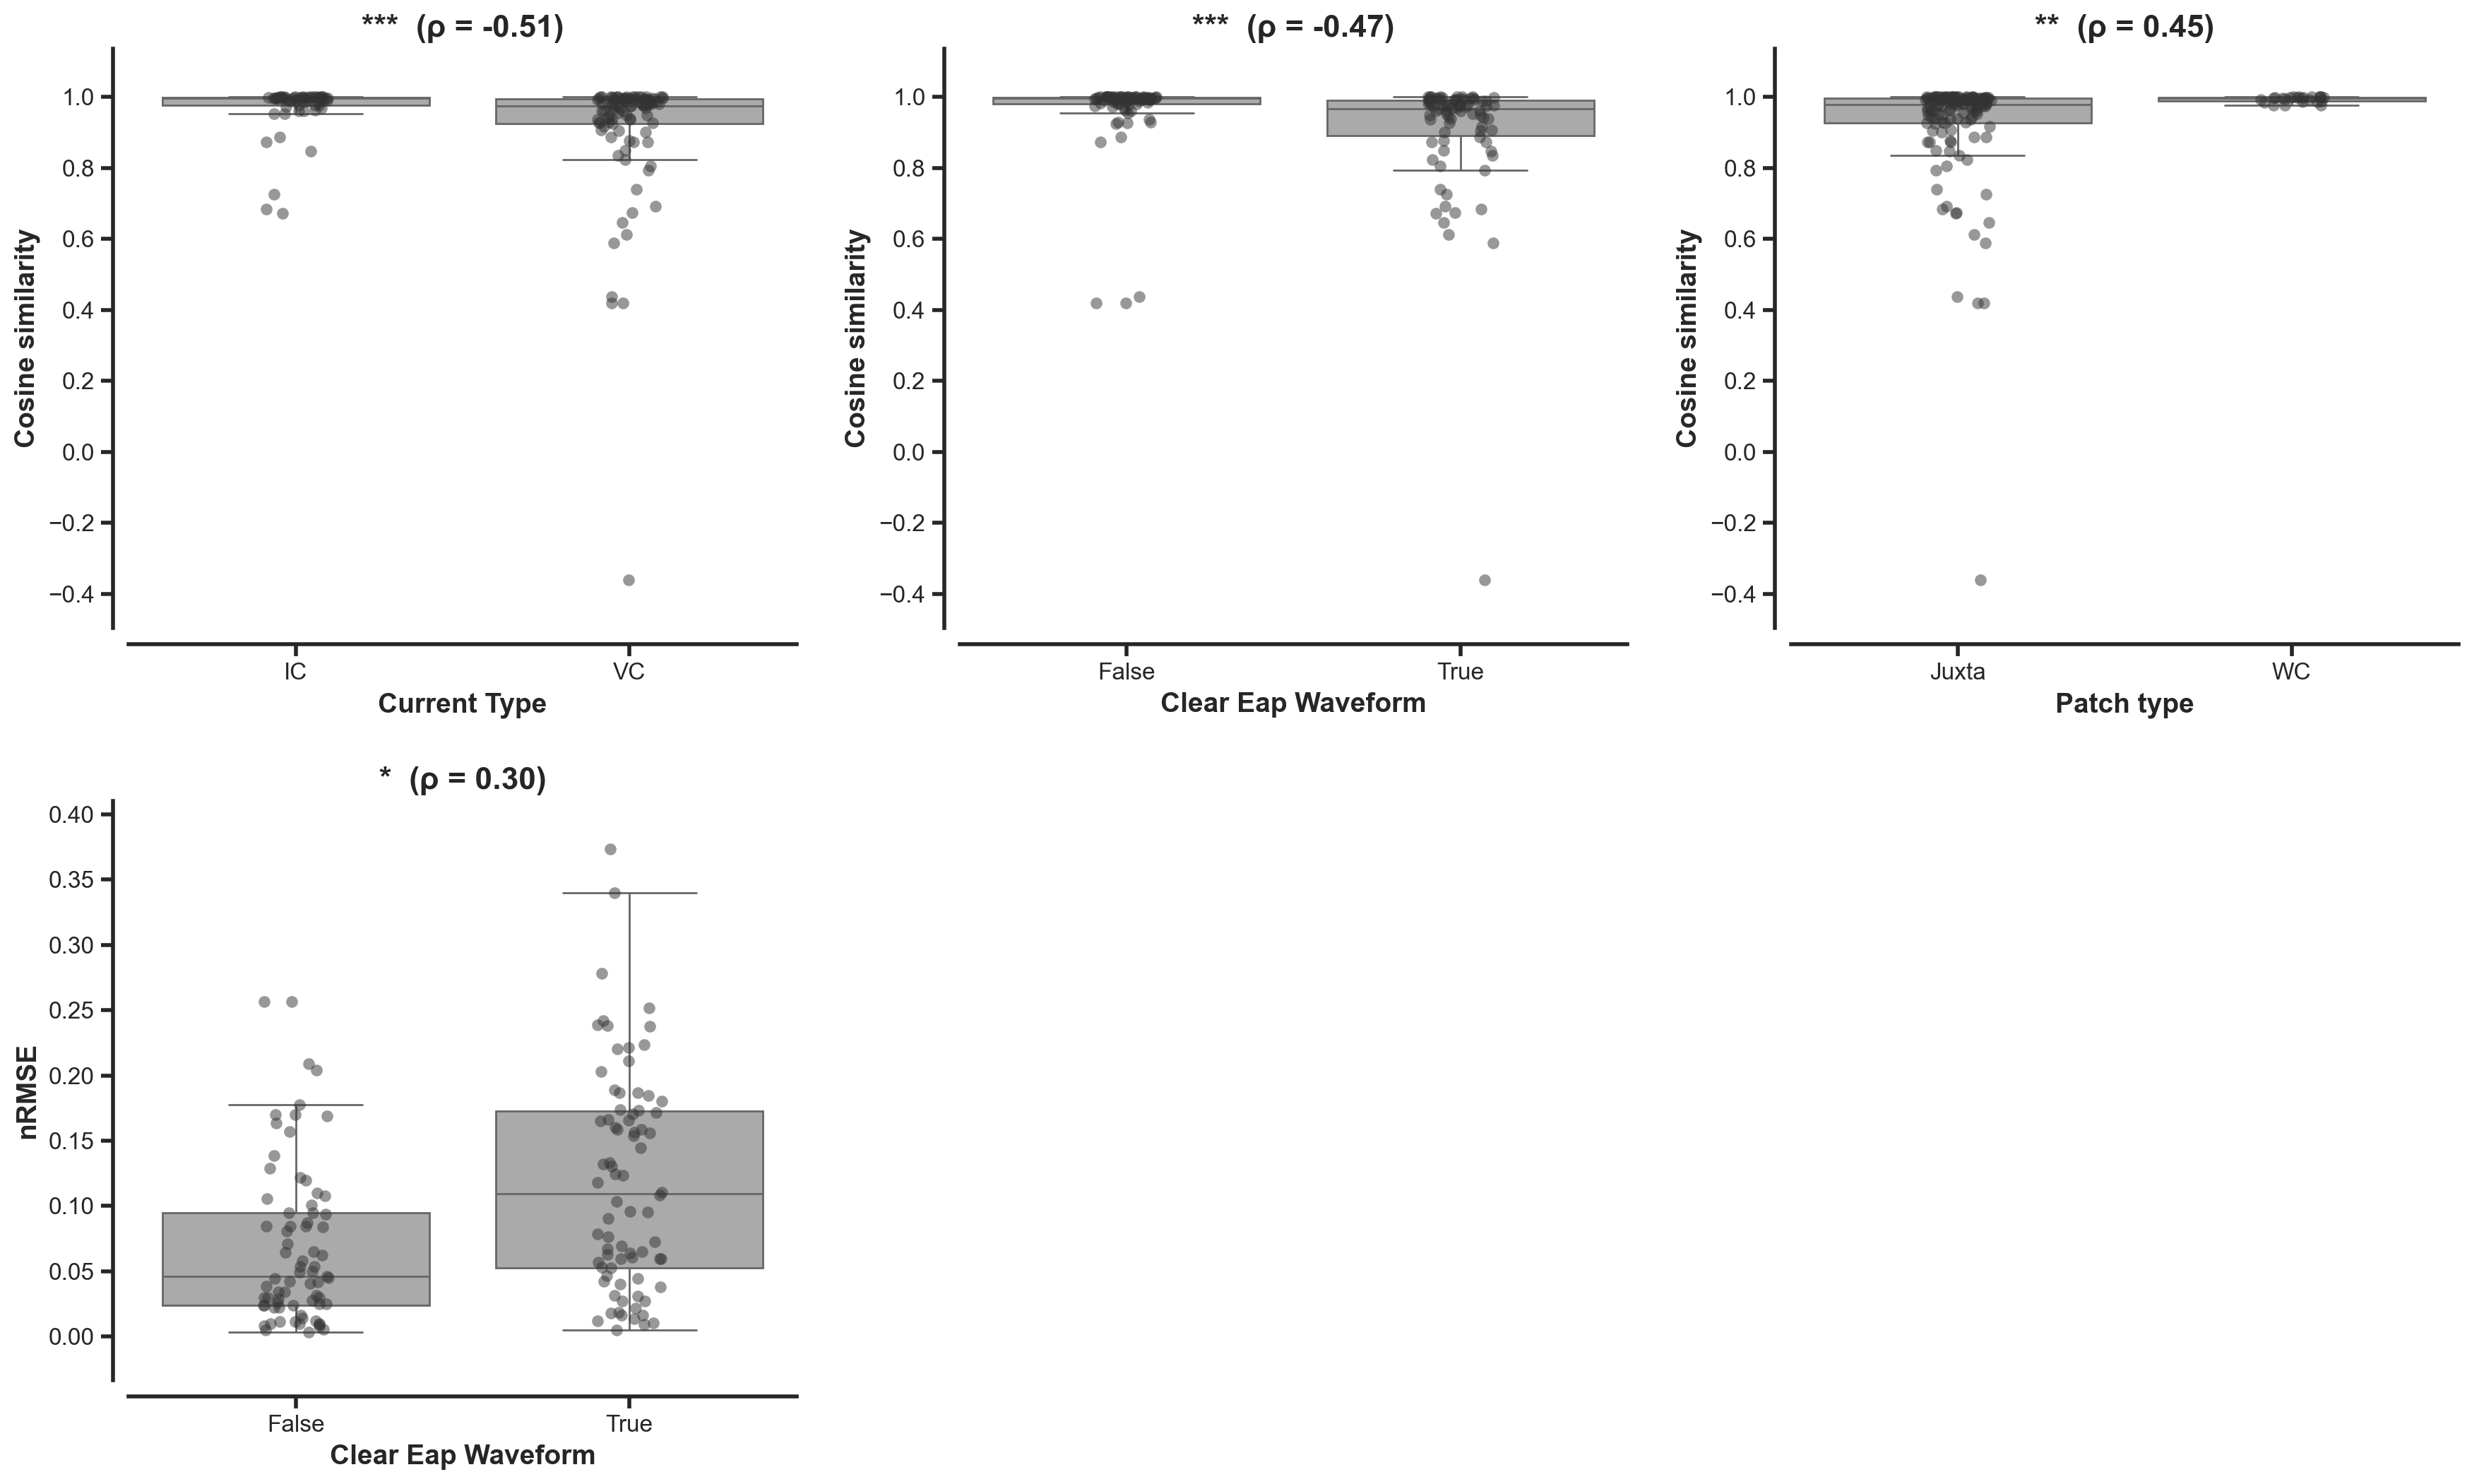

In [3]:
# Panel A: does recording/intrinsic metadata predict waveform separation between clusters?
sig_meta_clust_feats = analyze_cross_correlations(df_master)
plot_sig_feat_pairs(df_master, sig_meta_clust_feats)
plt.show()

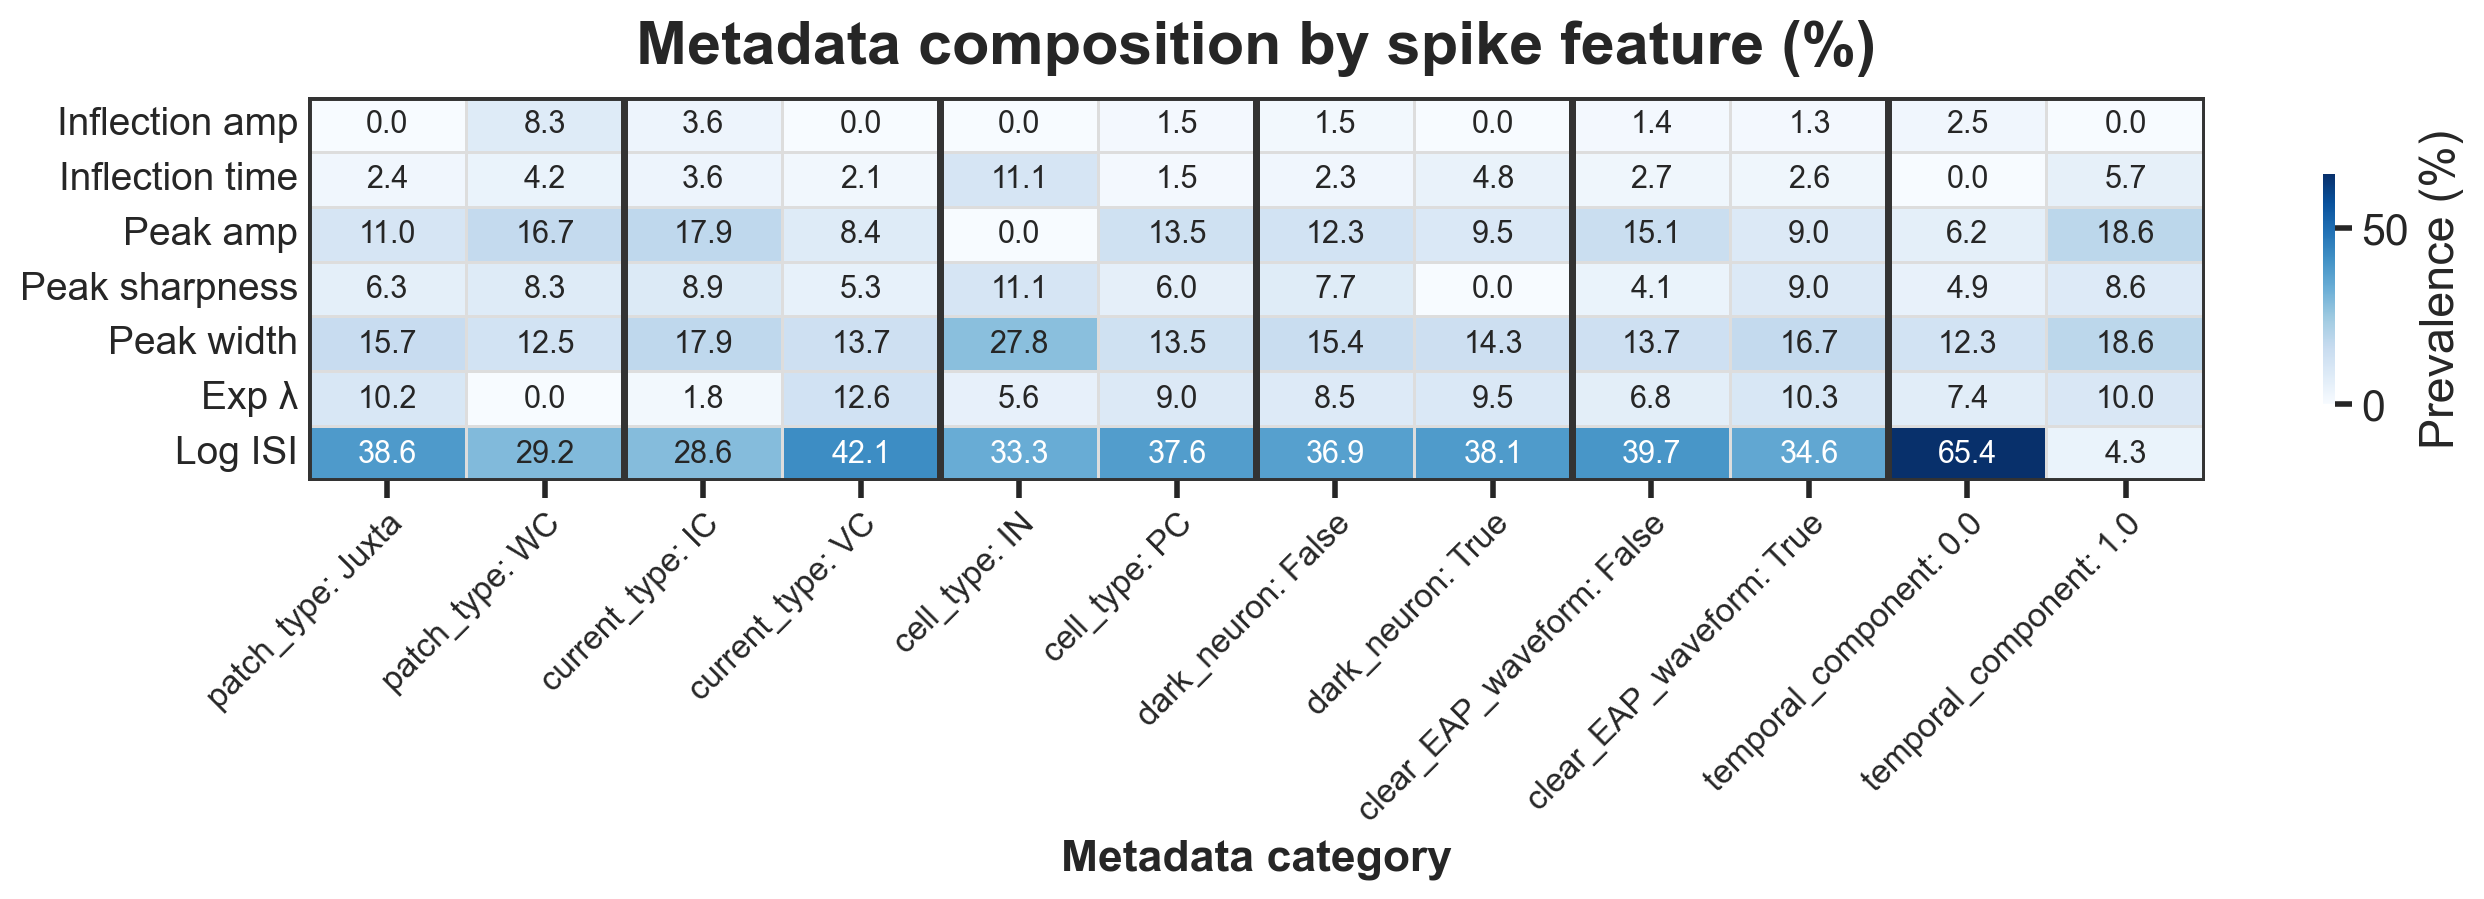

----------------------------------------
METADATA DEPENDENCY ANALYSIS (Chi-Square)
----------------------------------------
patch_type           | p = 0.0747 (ns)
current_type         | p = 0.0968 (ns)
cell_type            | p = 0.2118 (ns)
dark_neuron          | p = 0.9027 (ns)
clear_EAP_waveform   | p = 0.8205 (ns)
temporal_rho         | p = < 0.0001 (***)
temporal_p           | p = < 0.0001 (***)
temporal_component   | p = < 0.0001 (***)
----------------------------------------


In [4]:
# Panel B: does metadata predict which spike feature shows clustering?
plot_meta_spk_feature_dependency(df_master)
plt.show()
_ = stat_test_metadata_dependency(df_master)

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:1768: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([FEAT_LABELS.get(f, f) for f in feat_present],


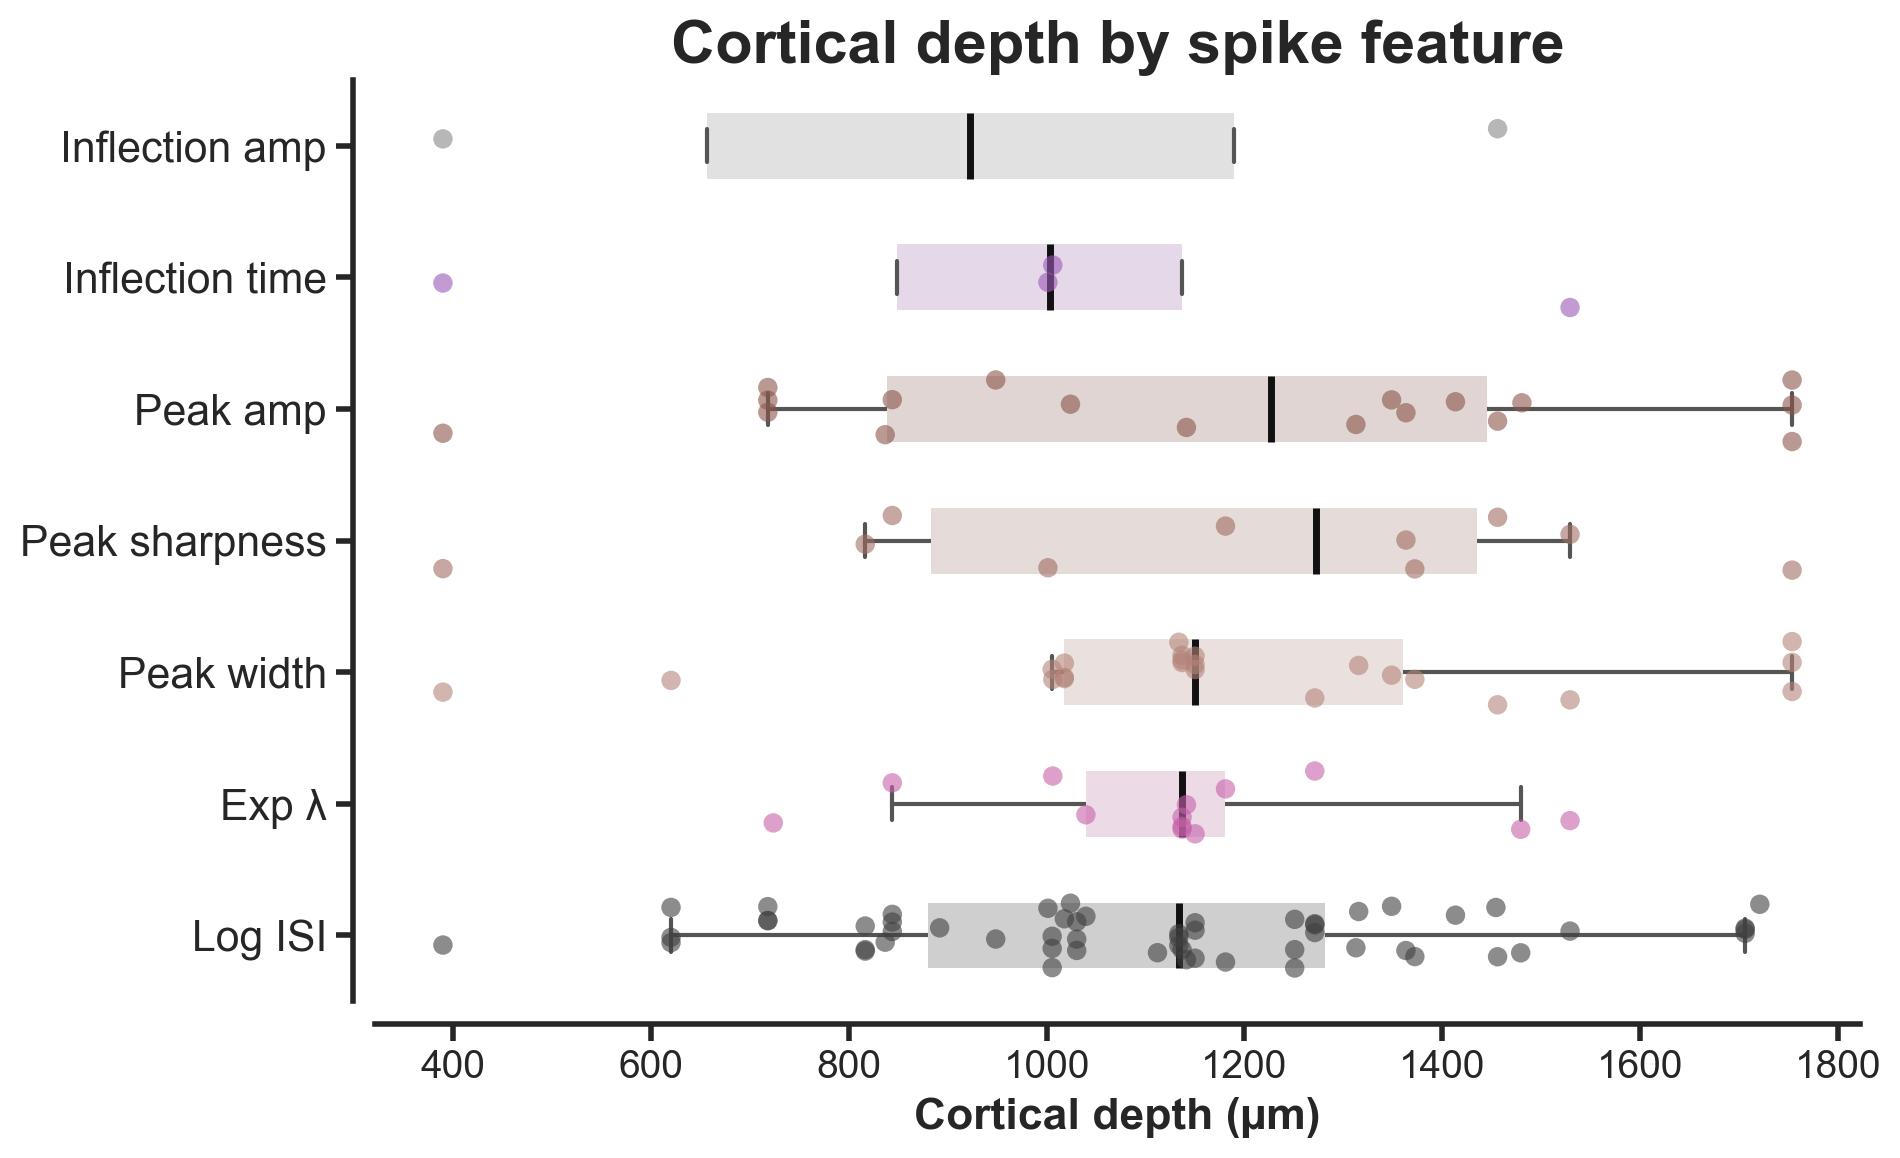

----------------------------------------
DEPTH STRATIFICATION ANALYSIS
----------------------------------------
Kruskal-Wallis H-stat: 9.174
p-value: 0.4214

No significant depth stratification found.
----------------------------------------


In [5]:
# Panel C: recording depth vs which spike feature clusters
plot_feature_depth_distribution(df_master)
plt.show()
_ = stat_test_depth_stratification(df_master)

**Supplementary Figure X. Relationship between cell and recording properties and spike waveform cluster differences.**

**(A)** Significant associations between metadata variables (intrinsic: cell type, cortical depth; recording: patch type, recording duration) and waveform separation between clusters (nRMSE, cosine similarity), assessed via Spearman correlation with BH-FDR correction. Only significant pairs shown.

**(B)** Association between metadata variables and which spike waveform feature shows clustering, assessed via chi-square (categorical variables) and Kruskal–Wallis (continuous variables) tests per feature.

**(C)** Distribution of recording depth across cells, split by which spike waveform feature exhibits clustering. No significant depth stratification indicates that waveform feature variability is not organized by cortical layer.